# Module 2: Where Do Elite Prospects Break?

**Question:** What pitch-level Statcast metrics differentiate prospects who convert tools into production from those who don't?

We focus on Volpe and Dominguez but compare them against the full prospect cohort to see if their weaknesses are common patterns or unique.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="urllib3")

import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from fire_fishman.data.statcast import get_statcast_pitches
from fire_fishman.data.prospects import get_prospect_df
from fire_fishman.features.pitch_level import (
    compute_plate_discipline,
    compute_whiff_by_pitch_type,
    compute_count_performance,
    compute_velo_tier_performance,
    compute_pitch_features_for_cohort,
)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 7)

In [2]:
pitches_2023 = get_statcast_pitches(2023)
pitches_2024 = get_statcast_pitches(2024)
pitches = pd.concat([pitches_2023, pitches_2024], ignore_index=True)

prospects = get_prospect_df()
batter_ids = prospects["mlbam_id"].tolist()

## 1. Plate Discipline Profiles

The first diagnostic: does MLB plate discipline hold up? Volpe reportedly had great discipline in the minors — did it survive the call-up?

In [3]:
# Compute full pitch-level features for all prospects
pitch_features = compute_pitch_features_for_cohort(pitches, batter_ids)
pitch_features = pitch_features.join(prospects.set_index("mlbam_id")[["name", "outcome"]])

# Discipline overview
discipline_cols = ["name", "outcome", "chase_rate", "zone_swing_rate", "zone_contact_rate", "whiff_rate"]
pitch_features[discipline_cols].sort_values("chase_rate", ascending=False)

,name,outcome,chase_rate,zone_swing_rate,zone_contact_rate,whiff_rate
batter_id,,,,,,
677594,Julio Rodriguez,star,0.392324,0.737167,0.834945,0.278089
682928,CJ Abrams,solid,0.372016,0.720997,0.853059,0.215340
678545,Ezequiel Tovar,solid,0.360465,0.761628,0.832061,0.233161
673962,Josh Jung,solid,0.352798,0.724605,0.840083,0.267823
677941,Jordyn Adams,bust,0.345029,0.736527,0.788618,0.297436
663611,Nick Madrigal,disappointing,0.339818,0.607362,0.967172,0.085044
677951,Bobby Witt Jr.,star,0.338630,0.721318,0.869289,0.202956
694192,Jackson Chourio,solid,0.333333,0.665010,0.866966,0.247461
672284,Jarred Kelenic,bust,0.311432,0.691120,0.806331,0.307692


/var/folders/4q/3jg7pd5n5p3cmvkd822n5j240000gn/T/ipykernel_8427/1206664605.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)
/var/folders/4q/3jg7pd5n5p3cmvkd822n5j240000gn/T/ipykernel_8427/1206664605.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)
/var/folders/4q/3jg7pd5n5p3cmvkd822n5j240000gn/T/ipykernel_8427/1206664605.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)
/var/folders/4q/3jg7pd5n5p3cmvkd822n5j240000gn/T/ipykernel_8427/1206664605.p

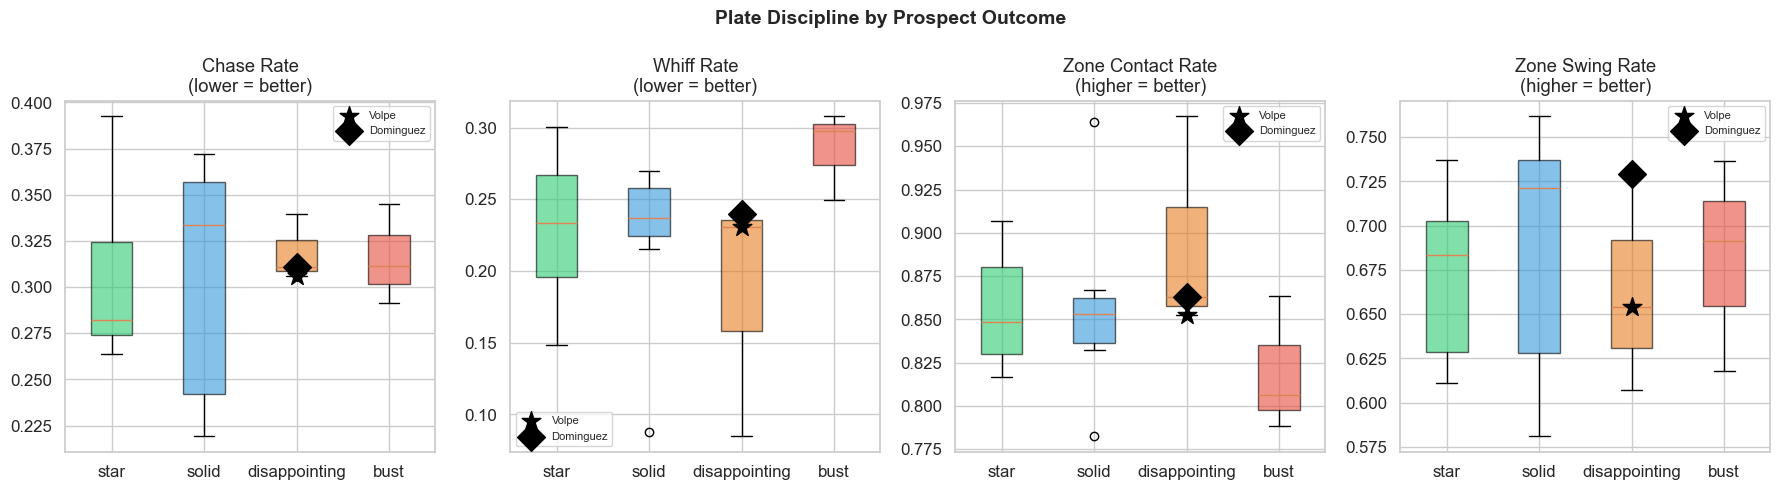

In [4]:
# Compare stars vs busts on discipline
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metrics = ["chase_rate", "whiff_rate", "zone_contact_rate", "zone_swing_rate"]
titles = ["Chase Rate\n(lower = better)", "Whiff Rate\n(lower = better)",
          "Zone Contact Rate\n(higher = better)", "Zone Swing Rate\n(higher = better)"]

for ax, metric, title in zip(axes, metrics, titles):
    order = ["star", "solid", "disappointing", "bust"]
    colors = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]
    data = [pitch_features[pitch_features["outcome"] == o][metric].dropna() for o in order]

    bp = ax.boxplot(data, labels=order, patch_artist=True)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    # Highlight Volpe + Dominguez
    for name, marker in [("Anthony Volpe", "*"), ("Jasson Dominguez", "D")]:
        row = pitch_features[pitch_features["name"] == name]
        if len(row) > 0 and not np.isnan(row[metric].values[0]):
            outcome_idx = order.index(row["outcome"].values[0]) + 1
            ax.scatter(outcome_idx, row[metric].values[0], marker=marker,
                      s=200, c="black", zorder=5, label=name.split()[-1])

    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Plate Discipline by Prospect Outcome", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/discipline_by_outcome.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Whiff Rate by Pitch Type

Where specifically are they getting exposed? Fastballs, breaking balls, or offspeed?

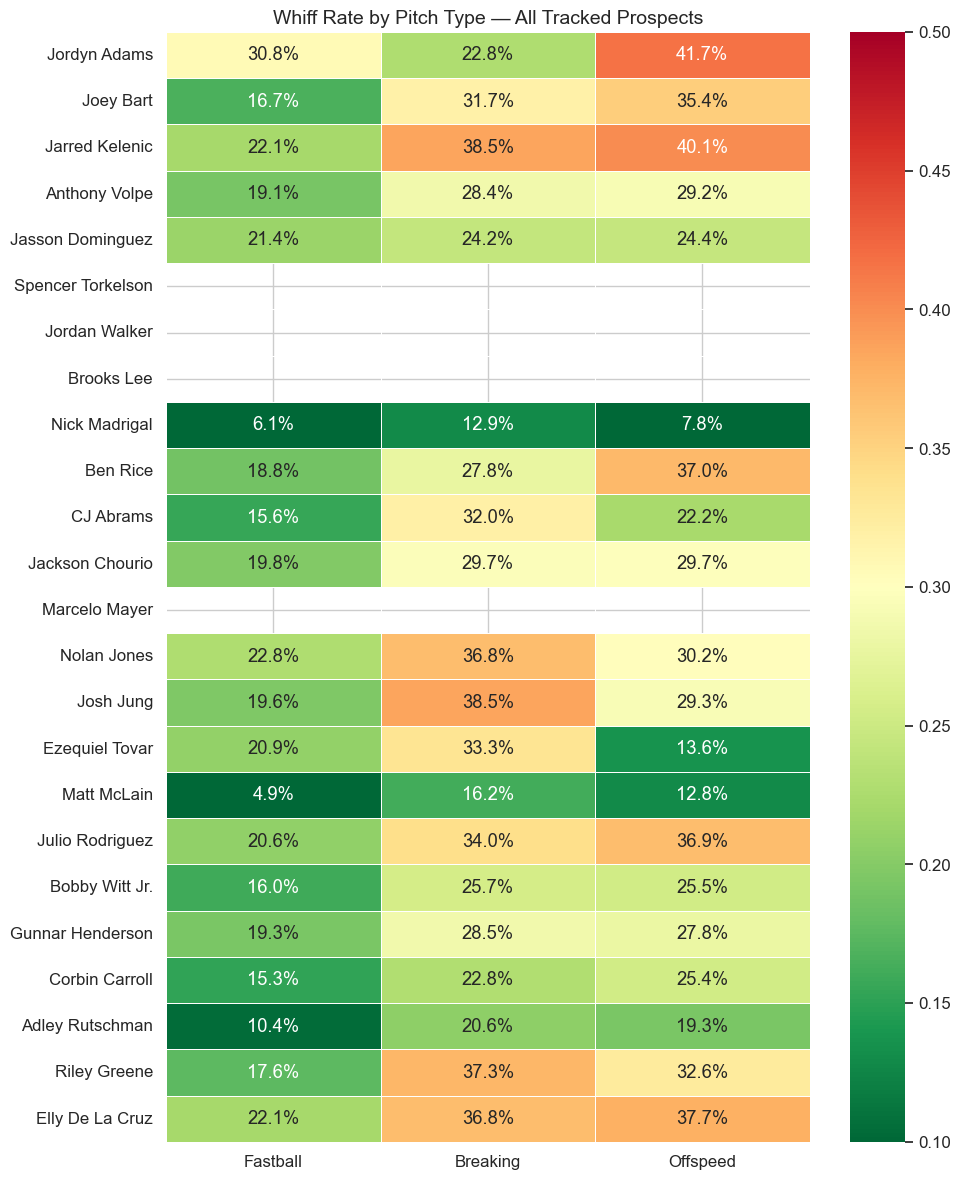

In [5]:
# Heatmap: whiff rate by pitch type, sorted by outcome
whiff_cols = ["whiff_rate_fastball", "whiff_rate_breaking", "whiff_rate_offspeed"]
whiff_data = pitch_features[["name", "outcome"] + whiff_cols].copy()
whiff_data = whiff_data.sort_values("outcome")

fig, ax = plt.subplots(figsize=(10, 12))
heatmap_data = whiff_data.set_index("name")[whiff_cols]
heatmap_data.columns = ["Fastball", "Breaking", "Offspeed"]

sns.heatmap(heatmap_data, annot=True, fmt=".1%", cmap="RdYlGn_r", ax=ax,
            linewidths=0.5, vmin=0.1, vmax=0.5)
ax.set_title("Whiff Rate by Pitch Type — All Tracked Prospects", fontsize=14)
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("../outputs/figures/whiff_by_pitch_type.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Velocity Vulnerability

Can they catch up to elite velocity? This is often the biggest minor-to-major adjustment.

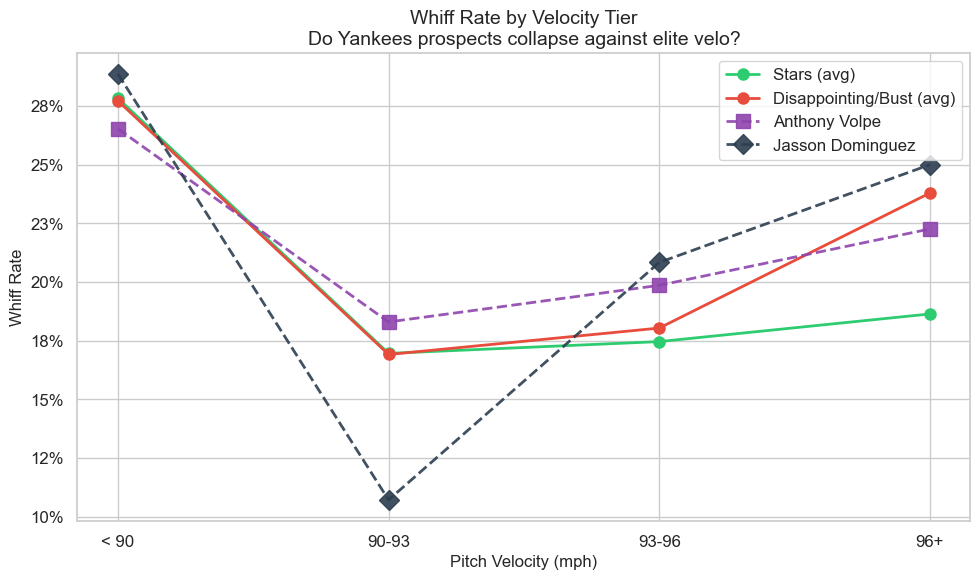

In [6]:
# Volpe and Dominguez vs. stars on velocity tiers
velo_cols = ["whiff_rate_soft_sub90", "whiff_rate_avg_90_93",
             "whiff_rate_hard_93_96", "whiff_rate_elite_96plus"]
velo_labels = ["< 90", "90-93", "93-96", "96+"]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot stars average
stars = pitch_features[pitch_features["outcome"] == "star"]
star_means = [stars[col].mean() for col in velo_cols]
ax.plot(velo_labels, star_means, "o-", color="#2ecc71", linewidth=2, markersize=8, label="Stars (avg)")

# Plot busts average
busts = pitch_features[pitch_features["outcome"].isin(["disappointing", "bust"])]
bust_means = [busts[col].mean() for col in velo_cols]
ax.plot(velo_labels, bust_means, "o-", color="#e74c3c", linewidth=2, markersize=8, label="Disappointing/Bust (avg)")

# Highlight Volpe + Dominguez
for name, color, marker in [("Anthony Volpe", "#8e44ad", "s"), ("Jasson Dominguez", "#2c3e50", "D")]:
    row = pitch_features[pitch_features["name"] == name]
    if len(row) > 0:
        vals = [row[col].values[0] for col in velo_cols]
        ax.plot(velo_labels, vals, f"{marker}--", color=color, linewidth=2, markersize=10,
                label=name, alpha=0.9)

ax.set_xlabel("Pitch Velocity (mph)", fontsize=12)
ax.set_ylabel("Whiff Rate", fontsize=12)
ax.set_title("Whiff Rate by Velocity Tier\nDo Yankees prospects collapse against elite velo?", fontsize=14)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.savefig("../outputs/figures/velo_vulnerability.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Count-Specific Collapse

Do they fall apart in pitcher's counts? Two-strike approach is often where prospects separate.

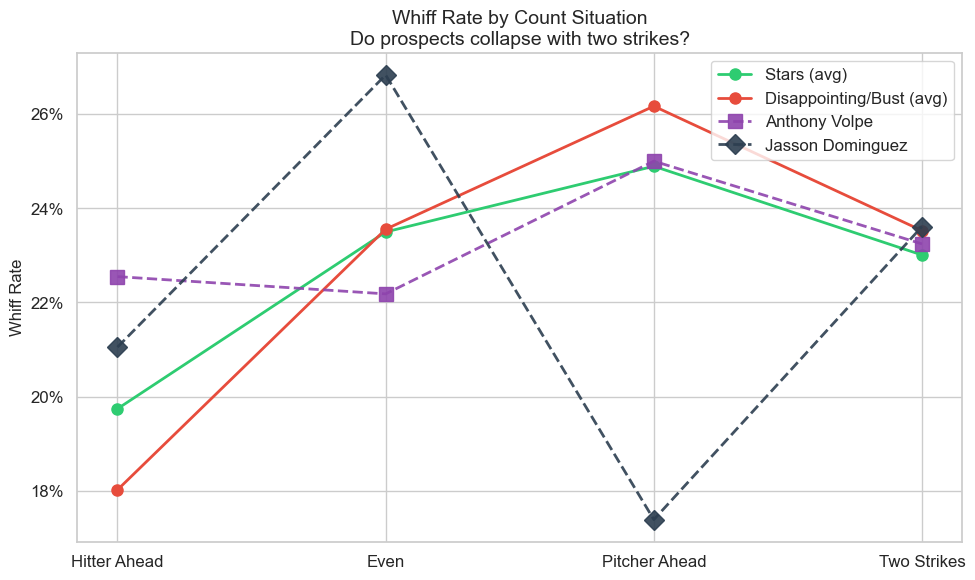

In [7]:
count_cols = ["whiff_rate_hitter_ahead", "whiff_rate_even",
              "whiff_rate_pitcher_ahead", "whiff_rate_two_strike"]
count_labels = ["Hitter Ahead", "Even", "Pitcher Ahead", "Two Strikes"]

fig, ax = plt.subplots(figsize=(10, 6))

stars = pitch_features[pitch_features["outcome"] == "star"]
star_means = [stars[col].mean() for col in count_cols]
ax.plot(count_labels, star_means, "o-", color="#2ecc71", linewidth=2, markersize=8, label="Stars (avg)")

busts = pitch_features[pitch_features["outcome"].isin(["disappointing", "bust"])]
bust_means = [busts[col].mean() for col in count_cols]
ax.plot(count_labels, bust_means, "o-", color="#e74c3c", linewidth=2, markersize=8, label="Disappointing/Bust (avg)")

for name, color, marker in [("Anthony Volpe", "#8e44ad", "s"), ("Jasson Dominguez", "#2c3e50", "D")]:
    row = pitch_features[pitch_features["name"] == name]
    if len(row) > 0:
        vals = [row[col].values[0] for col in count_cols]
        ax.plot(count_labels, vals, f"{marker}--", color=color, linewidth=2, markersize=10,
                label=name, alpha=0.9)

ax.set_ylabel("Whiff Rate", fontsize=12)
ax.set_title("Whiff Rate by Count Situation\nDo prospects collapse with two strikes?", fontsize=14)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.savefig("../outputs/figures/count_collapse.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Prospect Diagnostic Profiles

Radar-style summary for Volpe and Dominguez vs. the cohort.

In [8]:
# Percentile ranks within the cohort for key metrics
profile_cols = ["chase_rate", "whiff_rate", "zone_contact_rate",
                "whiff_rate_breaking", "whiff_rate_elite_96plus",
                "whiff_rate_two_strike"]
# For chase/whiff, lower is better -> invert percentile
invert = ["chase_rate", "whiff_rate", "whiff_rate_breaking",
          "whiff_rate_elite_96plus", "whiff_rate_two_strike"]

pct_df = pitch_features[profile_cols].copy()
for col in profile_cols:
    ranks = pct_df[col].rank(pct=True)
    if col in invert:
        ranks = 1 - ranks  # flip so higher = better
    pct_df[f"{col}_pct"] = ranks

pct_df["name"] = pitch_features["name"]

for name in ["Anthony Volpe", "Jasson Dominguez"]:
    row = pct_df[pct_df["name"] == name]
    if len(row) > 0:
        print(f"\n{'='*50}")
        print(f"{name} — Percentile Ranks (higher = better)")
        print(f"{'='*50}")
        for col in profile_cols:
            val = row[col].values[0]
            pct = row[f"{col}_pct"].values[0]
            label = col.replace("_", " ").title()
            bar = "█" * int(pct * 20)
            print(f"  {label:<30} {val:.1%}  [{bar:<20}] {pct:.0%}ile")


Anthony Volpe — Percentile Ranks (higher = better)
  Chase Rate                     30.6%  [███████████         ] 55%ile
  Whiff Rate                     23.1%  [█████████████       ] 65%ile
  Zone Contact Rate              85.2%  [██████████          ] 50%ile
  Whiff Rate Breaking            28.4%  [███████████         ] 55%ile
  Whiff Rate Elite 96Plus        22.3%  [███████             ] 35%ile
  Whiff Rate Two Strike          23.2%  [█████████████       ] 65%ile

Jasson Dominguez — Percentile Ranks (higher = better)
  Chase Rate                     31.1%  [█████████           ] 45%ile
  Whiff Rate                     24.0%  [█████████           ] 45%ile
  Zone Contact Rate              86.3%  [█████████████       ] 65%ile
  Whiff Rate Breaking            24.2%  [██████████████      ] 70%ile
  Whiff Rate Elite 96Plus        25.0%  [█████               ] 25%ile
  Whiff Rate Two Strike          23.6%  [████████████        ] 60%ile


## Key Findings

Summarize the diagnostic findings here after running the analysis. What specific vulnerabilities do Volpe and Dominguez have? How do they compare to prospects who successfully converted?

→ Continue to **Notebook 03** for the predictive model.